In [1]:
### VISUALIZING FEATURE AND WORKPIECE ###

import open3d as o3d

visualization = []

feature_path = "workpiece/workpiece31/surface1.stl"
source_workpiece = "workpiece/workpiece31/workpiece.stl"


mesh = o3d.io.read_triangle_mesh(source_workpiece)
mesh.compute_vertex_normals()
mesh_surface = o3d.io.read_triangle_mesh(feature_path)
mesh_surface.compute_vertex_normals()

pcd = o3d.geometry.PointCloud()
pcd = mesh.sample_points_poisson_disk(number_of_points=5000)
pcd.paint_uniform_color([0, 1, 0])
visualization.append(pcd)

pcd_surface = o3d.geometry.PointCloud()
pcd_surface = mesh_surface.sample_points_poisson_disk(number_of_points=5000)
pcd_surface.paint_uniform_color([1, 0, 0])
visualization.append(pcd_surface)

world_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=10, origin=[0, 0, 0])
visualization.append(world_frame)


o3d.visualization.draw_geometries(visualization)



Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [6]:
### CAD SIMULATION INTERSECTION ###

import open3d as o3d
import numpy as np
import math
import os

# ==========================================
# 1. CONFIGURATION
# ==========================================
EXPERIMENT = "test_6_noise"
NUMBER_OF_POINTS = 5000
VIEWPOINT_INDEX = 0
DISTANCE_TRESHOLD = 2.0

# Path to the feature or workpiece you want to intersect with
FEATURE_PATH = "workpiece/workpiece31/surface2.stl"

# Directory construction
PCD_FILENAME = f"viewpoint_simulated_{VIEWPOINT_INDEX}.pcd"
SIM_DIR = f"viewpoints_candidate/testing_data/{EXPERIMENT}"
pcd_path = os.path.join(SIM_DIR, PCD_FILENAME)


# ==========================================
# 2. VISUALIZATION FUNCTION
# ==========================================
def default_visualization(geometries, window_name="Default Visualization", zoom=1.0):
    azimuth_deg = -45
    elevation_deg = -135
    az = math.radians(azimuth_deg)
    el = math.radians(elevation_deg)
    
    # spherical → cartesian (camera front vector)
    front = np.array([
        math.cos(el) * math.cos(az),
        math.cos(el) * math.sin(az),
        math.sin(el)
    ])
    
    # Open3D camera looks toward object
    front = -front
    
    # Automatically calculate the center of the first point cloud
    if isinstance(geometries, list) and len(geometries) > 0:
        lookat = geometries[0].get_center()
    else:
        lookat = [0, 0, 0]
        
    up = [0, 0, 1]  # typical CAD Z-up

    o3d.visualization.draw_geometries(
        geometries,
        window_name=window_name,
        width=1024,
        height=768,
        lookat=lookat,
        up=up,
        front=front,
        zoom=zoom
    )


# ==========================================
# 3. LOAD DATA & CALCULATE INTERSECTION
# ==========================================

# Load the already simulated point cloud
simulated_pcd = o3d.io.read_point_cloud(pcd_path)
simulated_pcd.paint_uniform_color([0.5, 0.5, 0.5]) # Gray for the base simulated points

# Load the feature mesh
feature_mesh = o3d.io.read_triangle_mesh(FEATURE_PATH)
feature_mesh.compute_vertex_normals()

# Convert mesh to point cloud
feature_pcd = o3d.geometry.PointCloud()
feature_pcd = feature_mesh.sample_points_poisson_disk(number_of_points=NUMBER_OF_POINTS)
feature_pcd.paint_uniform_color([1, 0, 0]) # Red for the reference surface

# Compute distances from simulated_pcd to feature_pcd
dists = simulated_pcd.compute_point_cloud_distance(feature_pcd)
dists = np.asarray(dists)

# Find points within a very small threshold
intersection_indices = np.where(dists < DISTANCE_TRESHOLD)[0]
intersection_sim_pcd = simulated_pcd.select_by_index(intersection_indices)

# Paint the intersecting points blue
intersection_sim_pcd.paint_uniform_color([0, 0, 1])

print(f"Found {len(intersection_indices)} intersecting points between the CAD and the Feature!")


# ==========================================
# 4. SHOW RESULTS
# ==========================================

# Visualize it using the custom default camera angles!
default_visualization([simulated_pcd, feature_pcd], window_name=f"Simulated PCD & Feature ({EXPERIMENT})", zoom=1.0)

if len(intersection_indices) > 0:
    default_visualization([intersection_sim_pcd], window_name=f"Intersection Only ({EXPERIMENT})", zoom=1.0)
else:
    print("No intersection points to show!")


Found 5420 intersecting points between the CAD and the Feature!


In [4]:
# default_visualization([simulated_pcd])
simulated_pcd

PointCloud with 12025 points.

In [7]:
### ACTUAL INTERSECTION ###

import open3d as o3d
import numpy as np
import os

# ==========================================
# 1. PATH CONFIGURATION 
# (Reuses EXPERIMENT, PCD_FILENAME, feature_pcd, and default_visualization from the block above)
# ==========================================
actual_pcd_path = f"processed_data/{EXPERIMENT}/{PCD_FILENAME}"
transform_path = f"evaluation_result/{EXPERIMENT}/merge_full_transformation.npy"


# ==========================================
# 2. LOAD & TRANSFORM ACTUAL REAL SCAN
# ==========================================
if os.path.exists(actual_pcd_path) and os.path.exists(transform_path):
    # Load the specific point cloud
    actual_pcd = o3d.io.read_point_cloud(actual_pcd_path)
    actual_pcd.paint_uniform_color([0.2, 0.8, 0.2]) # Green for the actual scan

    # Load the transformation matrix
    transformation_matrix = np.load(transform_path)

    # --- Compute and apply the INVERSE transformation ---
    # This brings the actual scan back into the CAD world coordinate frame!
    inverse_transformation = np.linalg.inv(transformation_matrix)
    actual_pcd.transform(inverse_transformation)


    # ==========================================
    # 3. CALCULATE INTERSECTION 
    # ==========================================
    dists = actual_pcd.compute_point_cloud_distance(feature_pcd)
    dists = np.asarray(dists)

    intersection_indices = np.where(dists < DISTANCE_TRESHOLD)[0]
    intersection_actual_pcd = actual_pcd.select_by_index(intersection_indices)

    # Paint the intersecting points blue
    intersection_actual_pcd.paint_uniform_color([0, 0, 1])

    print(f"Found {len(intersection_indices)} intersecting points between Actual Scan and Feature!")


    
    # ==========================================
    # 3.5 CALCULATE CHAMFER DISTANCE
    # ==========================================
    if len(intersection_indices) > 0:
        # Distance from Sim to Actual
        dists_s2a = np.asarray(intersection_sim_pcd.compute_point_cloud_distance(intersection_actual_pcd))
        
        # Distance from Actual to Sim
        dists_a2s = np.asarray(intersection_actual_pcd.compute_point_cloud_distance(intersection_sim_pcd))
        
        # Chamfer Distance (symmetric mean)
        chamfer_dist = np.mean(dists_s2a) + np.mean(dists_a2s)
        
        print(f"==========================================")
        print(f"CHAMFER DISTANCE (Simulated vs Actual Intersection): {chamfer_dist:.6f} mm")
        print(f"==========================================")

    # ==========================================
    # 4. SHOW RESULTS
    # ==========================================
    world_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=20, origin=[0, 0, 0])

    # Visualize everything together
    default_visualization([actual_pcd, feature_pcd], window_name=f"Actual Scan & Feature ({EXPERIMENT})", zoom=1.0)
    
    # Visualize just the intersection
    if len(intersection_indices) > 0:
        default_visualization([intersection_actual_pcd], window_name=f"Actual Intersection Only ({EXPERIMENT})", zoom=1.0)
else:
    print(f"Error: Missing {actual_pcd_path} or {transform_path}")


Found 3796 intersecting points between Actual Scan and Feature!
CHAMFER DISTANCE (Simulated vs Actual Intersection): 8.278417 mm


In [8]:
# o3d.visualization.draw_geometries([actual_pcd])
# o3d.visualization.draw_geometries([intersection_actual_pcd])

actual_pcd

PointCloud with 26768 points.

Capturing 4 images in the background...
Saved 2x2 Grid to: comparison_grid_test_6_noise_view_0.png


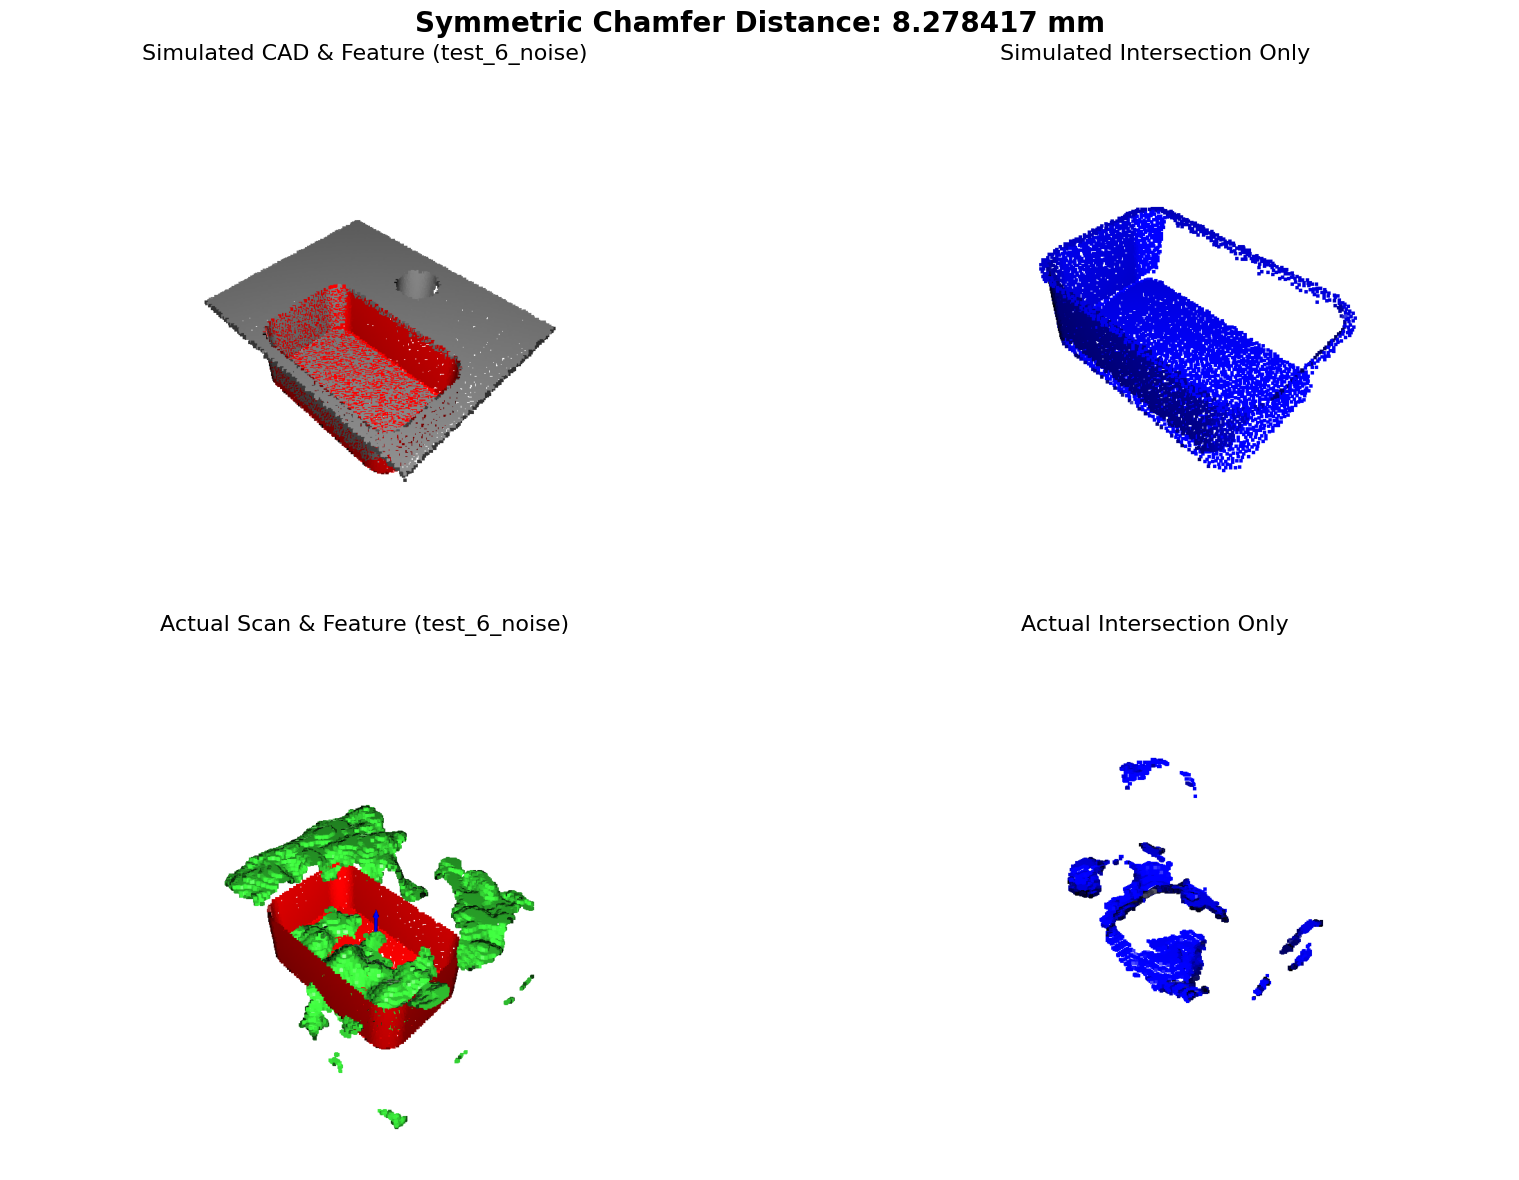

In [9]:
### VISUALIZATION ###

import matplotlib.pyplot as plt

# ==========================================
# 5. CAPTURE AND SAVE 2x2 IMAGE GRID
# ==========================================
def capture_visualization_image(geometries, zoom=1.0):
    azimuth_deg = -45
    elevation_deg = -135
    az = math.radians(azimuth_deg)
    el = math.radians(elevation_deg)
    front = np.array([
        math.cos(el) * math.cos(az),
        math.cos(el) * math.sin(az),
        math.sin(el)
    ])
    front = -front
    
    if isinstance(geometries, list) and len(geometries) > 0:
        lookat = geometries[0].get_center()
    else:
        lookat = [0, 0, 0]
    up = [0, 0, 1]
    
    vis = o3d.visualization.Visualizer()
    vis.create_window(visible=False, width=1024, height=768)
    for geom in geometries:
        vis.add_geometry(geom)
        
    ctr = vis.get_view_control()
    ctr.set_lookat(lookat)
    ctr.set_up(up)
    ctr.set_front(front)
    ctr.set_zoom(zoom)
    
    # Render two frames to ensure it completely loads
    vis.poll_events()
    vis.update_renderer()
    vis.poll_events()
    vis.update_renderer()
    
    img = np.asarray(vis.capture_screen_float_buffer(do_render=True))
    vis.destroy_window()
    return img

print("Capturing 4 images in the background...")

# 1. Capture Simulated + Feature [0, 0]
img_sim = capture_visualization_image([simulated_pcd, feature_pcd])

# 2. Capture Simulated Intersection [0, 1]
if len(intersection_sim_pcd.points) > 0:
    img_sim_int = capture_visualization_image([intersection_sim_pcd])
else:
    img_sim_int = np.ones((768, 1024, 3)) # Blank white image

# 3. Capture Actual + Feature [1, 0]
world_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=20, origin=[0, 0, 0])
img_act = capture_visualization_image([actual_pcd, feature_pcd, world_frame])

# 4. Capture Actual Intersection [1, 1]
if len(intersection_actual_pcd.points) > 0:
    img_act_int = capture_visualization_image([intersection_actual_pcd])
else:
    img_act_int = np.ones((768, 1024, 3)) # Blank white image

# Plot as 2x2 Grid
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

axs[0, 0].imshow(img_sim)
axs[0, 0].set_title(f"Simulated CAD & Feature ({EXPERIMENT})", fontsize=16)
axs[0, 0].axis('off')

axs[0, 1].imshow(img_sim_int)
axs[0, 1].set_title(f"Simulated Intersection Only", fontsize=16)
axs[0, 1].axis('off')

axs[1, 0].imshow(img_act)
axs[1, 0].set_title(f"Actual Scan & Feature ({EXPERIMENT})", fontsize=16)
axs[1, 0].axis('off')

axs[1, 1].imshow(img_act_int)
axs[1, 1].set_title(f"Actual Intersection Only", fontsize=16)
axs[1, 1].axis('off')

# Add Chamfer distance as a super title if it was calculated
if 'chamfer_dist' in locals() or 'chamfer_dist' in globals():
    fig.suptitle(f"Symmetric Chamfer Distance: {chamfer_dist:.6f} mm", fontsize=20, fontweight='bold')

plt.tight_layout()

# Save the plot
save_path = f"comparison_grid_{EXPERIMENT}_view_{VIEWPOINT_INDEX}.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved 2x2 Grid to: {save_path}")

plt.show()


In [10]:
### AUTOMATIC BATCH SURFACE ANALYSIS ###

import os
import glob
import numpy as np
import open3d as o3d
import math
import matplotlib.pyplot as plt
import csv
import re

# ==========================================
# 1. BATCH CONFIGURATION
# ==========================================
EXPERIMENT = "test_6_noise"
NUMBER_OF_POINTS = 5000
DISTANCE_THRESHOLD = 2.0

# Input Directories
WORKPIECE_DIR = "workpiece/workpiece3"
SIM_DIR = f"viewpoints_candidate/testing_data/{EXPERIMENT}"
ACTUAL_DIR = f"processed_data/{EXPERIMENT}"
TRANSFORM_DIR = f"evaluation_result/{EXPERIMENT}"

# Output Directory
OUTPUT_DIR = f"surface/{EXPERIMENT}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CSV_OUTPUT_PATH = os.path.join(OUTPUT_DIR, "chamfer_results.csv")


# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================
def default_visualization_headless(geometries, zoom=1.0):
    azimuth_deg = -45
    elevation_deg = -135
    az = math.radians(azimuth_deg)
    el = math.radians(elevation_deg)
    
    front = np.array([math.cos(el)*math.cos(az), math.cos(el)*math.sin(az), math.sin(el)])
    front = -front
    
    if isinstance(geometries, list) and len(geometries) > 0 and len(geometries[0].points) > 0:
        lookat = geometries[0].get_center()
    else:
        lookat = [0, 0, 0]
        
    up = [0, 0, 1]  

    vis = o3d.visualization.Visualizer()
    vis.create_window(visible=False, width=1024, height=768)
    for geom in geometries:
        vis.add_geometry(geom)
        
    ctr = vis.get_view_control()
    ctr.set_lookat(lookat)
    ctr.set_up(up)
    ctr.set_front(front)
    ctr.set_zoom(zoom)
    
    vis.poll_events()
    vis.update_renderer()
    vis.poll_events()
    vis.update_renderer()
    
    img = np.asarray(vis.capture_screen_float_buffer(do_render=True))
    vis.destroy_window()
    return img


# ==========================================
# 3. MAIN BATCH PIPELINE
# ==========================================
def run_pipeline():
    # Find all surfaceX.stl files (ignore workpiece.stl)
    stl_files = glob.glob(os.path.join(WORKPIECE_DIR, "surface*.stl"))
    print(f"Found {len(stl_files)} feature surfaces to process.")
    
    # Find all viewpoint_pose_X.npy to get valid viewpoint indices
    pose_files = glob.glob(os.path.join(SIM_DIR, "viewpoint_pose_*.npy"))
    viewpoint_indices = []
    for pf in pose_files:
        match = re.search(r'viewpoint_pose_(\d+)\.npy', os.path.basename(pf))
        if match:
            viewpoint_indices.append(int(match.group(1)))
    # viewpoint_indices = sorted(list(set(viewpoint_indices)))
    viewpoint_indices = sorted(list(set(viewpoint_indices)))[:71]

    print(f"Found {len(viewpoint_indices)} viewpoints to process.")

    results = []

    for stl_path in stl_files:
        surface_name = os.path.splitext(os.path.basename(stl_path))[0]
        print(f"\n---> PROCESSING FEATURE: {surface_name}")
        
        # Load and sample feature
        feature_mesh = o3d.io.read_triangle_mesh(stl_path)
        feature_mesh.compute_vertex_normals()
        feature_pcd = feature_mesh.sample_points_poisson_disk(number_of_points=NUMBER_OF_POINTS)
        feature_pcd.paint_uniform_color([1, 0, 0]) # Red
        
        for vp_idx in viewpoint_indices:
            print(f"  -> Viewpoint {vp_idx}")
            
            # Paths
            pcd_filename = f"viewpoint_simulated_{vp_idx}.pcd"
            sim_pcd_path = os.path.join(SIM_DIR, pcd_filename)
            actual_pcd_path = os.path.join(ACTUAL_DIR, pcd_filename)
            transform_path = os.path.join(TRANSFORM_DIR, "merge_full_transformation.npy")
            
            if not os.path.exists(sim_pcd_path) or not os.path.exists(actual_pcd_path):
                print(f"     Skipping Viewpoint {vp_idx} (Missing point cloud files)")
                continue
                
            # 1. Process Simulated
            sim_pcd = o3d.io.read_point_cloud(sim_pcd_path)
            sim_pcd.paint_uniform_color([0.5, 0.5, 0.5])
            
            dists_sim = np.asarray(sim_pcd.compute_point_cloud_distance(feature_pcd))
            int_sim_indices = np.where(dists_sim < DISTANCE_THRESHOLD)[0]
            int_sim_pcd = sim_pcd.select_by_index(int_sim_indices)
            int_sim_pcd.paint_uniform_color([0, 0, 1])
            
            # 2. Process Actual
            actual_pcd = o3d.io.read_point_cloud(actual_pcd_path)
            actual_pcd.paint_uniform_color([0.2, 0.8, 0.2])
            
            if os.path.exists(transform_path):
                T = np.load(transform_path)
                actual_pcd.transform(np.linalg.inv(T))
                
            dists_act = np.asarray(actual_pcd.compute_point_cloud_distance(feature_pcd))
            int_act_indices = np.where(dists_act < DISTANCE_THRESHOLD)[0]
            int_act_pcd = actual_pcd.select_by_index(int_act_indices)
            int_act_pcd.paint_uniform_color([0, 0, 1])
            
            # 3. Calculate Chamfer
            chamfer_dist = -1.0
            if len(int_sim_indices) > 0 and len(int_act_indices) > 0:
                d1 = np.asarray(int_sim_pcd.compute_point_cloud_distance(int_act_pcd))
                d2 = np.asarray(int_act_pcd.compute_point_cloud_distance(int_sim_pcd))
                chamfer_dist = np.mean(d1) + np.mean(d2)
            
            # Save results
            results.append({
                'Feature': surface_name,
                'Viewpoint': vp_idx,
                'Sim_Intersection_Points': len(int_sim_indices),
                'Actual_Intersection_Points': len(int_act_indices),
                'Chamfer_Distance_mm': chamfer_dist
            })
            
            # 4. Generate & Save Image
            world_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=20, origin=[0, 0, 0])
            
            img_sim = default_visualization_headless([sim_pcd, feature_pcd])
            img_sim_int = default_visualization_headless([int_sim_pcd]) if len(int_sim_indices) > 0 else np.ones((768, 1024, 3))
            img_act = default_visualization_headless([actual_pcd, feature_pcd])
            img_act_int = default_visualization_headless([int_act_pcd]) if len(int_act_indices) > 0 else np.ones((768, 1024, 3))
            
            fig, axs = plt.subplots(2, 2, figsize=(16, 12))
            axs[0, 0].imshow(img_sim); axs[0, 0].set_title(f"Simulated CAD & Feature", fontsize=16); axs[0, 0].axis('off')
            axs[0, 1].imshow(img_sim_int); axs[0, 1].set_title(f"Simulated Intersection Only", fontsize=16); axs[0, 1].axis('off')
            axs[1, 0].imshow(img_act); axs[1, 0].set_title(f"Actual Scan & Feature", fontsize=16); axs[1, 0].axis('off')
            axs[1, 1].imshow(img_act_int); axs[1, 1].set_title(f"Actual Intersection Only", fontsize=16); axs[1, 1].axis('off')
            
            if chamfer_dist >= 0:
                fig.suptitle(f"{surface_name} - View {vp_idx} | Chamfer: {chamfer_dist:.4f} mm", fontsize=20, fontweight='bold')
            else:
                fig.suptitle(f"{surface_name} - View {vp_idx} | Chamfer: N/A", fontsize=20, fontweight='bold')
                
            plt.tight_layout()
            
            img_filename = f"{surface_name}_view_{vp_idx}.png"
            plt.savefig(os.path.join(OUTPUT_DIR, img_filename), dpi=150, bbox_inches='tight')
            plt.close(fig)

    # ==========================================
    # 5. WRITE CSV SUMMARY
    # ==========================================
    if results:
        with open(CSV_OUTPUT_PATH, mode='w', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=results[0].keys())
            writer.writeheader()
            writer.writerows(results)
        print(f"\nPipeline complete! Results saved to {CSV_OUTPUT_PATH}")

if __name__ == "__main__":
    run_pipeline()


Found 3 feature surfaces to process.
Found 24 viewpoints to process.

---> PROCESSING FEATURE: surface4
  -> Viewpoint 0
  -> Viewpoint 1
  -> Viewpoint 2
  -> Viewpoint 3
  -> Viewpoint 4
  -> Viewpoint 5
  -> Viewpoint 6
  -> Viewpoint 7
  -> Viewpoint 8
  -> Viewpoint 9
  -> Viewpoint 10
  -> Viewpoint 11
  -> Viewpoint 12
  -> Viewpoint 13
  -> Viewpoint 14
  -> Viewpoint 15
  -> Viewpoint 16
  -> Viewpoint 17
  -> Viewpoint 18
  -> Viewpoint 19
  -> Viewpoint 20
  -> Viewpoint 21
  -> Viewpoint 22
  -> Viewpoint 23

---> PROCESSING FEATURE: surface5
  -> Viewpoint 0
  -> Viewpoint 1
  -> Viewpoint 2
  -> Viewpoint 3
  -> Viewpoint 4
  -> Viewpoint 5
  -> Viewpoint 6
  -> Viewpoint 7
  -> Viewpoint 8
  -> Viewpoint 9
  -> Viewpoint 10
  -> Viewpoint 11
  -> Viewpoint 12
  -> Viewpoint 13
  -> Viewpoint 14
  -> Viewpoint 15
  -> Viewpoint 16
  -> Viewpoint 17
  -> Viewpoint 18
  -> Viewpoint 19
  -> Viewpoint 20
  -> Viewpoint 21
  -> Viewpoint 22
  -> Viewpoint 23

---> PROCESSING 

--- COMPARING INPUT SIMULATED PCDS ---
Best View (17) Point Count: 18990
Worst View (47) Point Count: 15358
Best View (17) Mean AoI: 56.27 degrees
Worst View (47) Mean AoI: 49.79 degrees
Saved histogram to input_differentiation_check.png


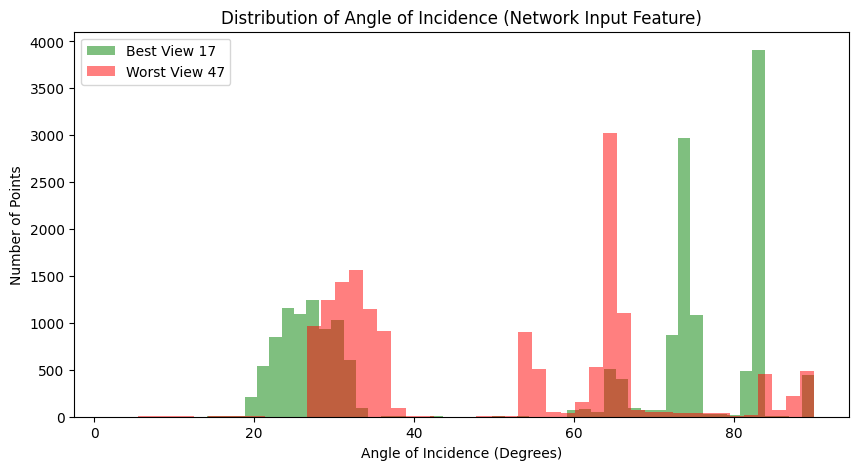

In [11]:
### CHECK INPUT - AOI DIFFERENCE ###


import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
import os

EXPERIMENT = "test_5_090angle" # Change if using a different one
BEST_VIEW = 17   # e.g. view0 for Surface1
WORST_VIEW = 47 # e.g. view43 for Surface1

# Load simulated PCDs
dir_path = f"viewpoints_candidate/testing_data/{EXPERIMENT}"
best_pcd = o3d.io.read_point_cloud(os.path.join(dir_path, f"viewpoint_simulated_{BEST_VIEW}.pcd"))
worst_pcd = o3d.io.read_point_cloud(os.path.join(dir_path, f"viewpoint_simulated_{WORST_VIEW}.pcd"))

print(f"--- COMPARING INPUT SIMULATED PCDS ---")
print(f"Best View ({BEST_VIEW}) Point Count: {len(best_pcd.points)}")
print(f"Worst View ({WORST_VIEW}) Point Count: {len(worst_pcd.points)}")

# Extract Angle of Incidence (assuming we stored it, or we can recalculate it)
# Since the network uses AoI, let's recalculate it to see the difference
def get_aoi(pcd, view_idx):
    xyz = np.asarray(pcd.points)
    normals = np.asarray(pcd.normals)
    
    # Load camera pose
    tf_path = os.path.join(dir_path, f"viewpoint_pose_{view_idx}.npy")
    if os.path.exists(tf_path):
        T_obj_cam = np.load(tf_path)
        camera_pos = T_obj_cam[:3, 3] # Camera position in object frame
    else:
        return np.zeros(len(xyz))
        
    V = camera_pos - xyz
    V_norm = np.linalg.norm(V, axis=1, keepdims=True)
    V_normalized = V / (V_norm + 1e-6)
    
    N_norm = np.linalg.norm(normals, axis=1, keepdims=True)
    N_normalized = normals / (N_norm + 1e-6)
    
    aoi_cos = np.sum(V_normalized * N_normalized, axis=1)
    aoi_deg = np.degrees(np.arccos(np.clip(aoi_cos, 0, 1)))
    return aoi_deg

aoi_best = get_aoi(best_pcd, BEST_VIEW)
aoi_worst = get_aoi(worst_pcd, WORST_VIEW)

print(f"Best View ({BEST_VIEW}) Mean AoI: {np.mean(aoi_best):.2f} degrees")
print(f"Worst View ({WORST_VIEW}) Mean AoI: {np.mean(aoi_worst):.2f} degrees")

# Plot Histograms
plt.figure(figsize=(10, 5))
plt.hist(aoi_best, bins=50, alpha=0.5, label=f'Best View {BEST_VIEW}', color='green')
plt.hist(aoi_worst, bins=50, alpha=0.5, label=f'Worst View {WORST_VIEW}', color='red')
plt.title("Distribution of Angle of Incidence (Network Input Feature)")
plt.xlabel("Angle of Incidence (Degrees)")
plt.ylabel("Number of Points")
plt.legend()
plt.savefig("input_differentiation_check.png")
print("Saved histogram to input_differentiation_check.png")
